# Can a smart model beat a simple rule? My FPL season, tested.

**Season:** 2025/26 &nbsp;•&nbsp; **My team:** entry 816200 (finished top ~3.5%)

Each week in Fantasy Premier League I pick transfers and a captain. I wanted one clear answer:

> **Which signals from past gameweeks would have helped me make better choices for the next 4 gameweeks?**

So I tested signals on the whole 2025/26 season. I also built a prediction model and asked a harder question: **does the model make better choices than a simple rule?**

One note before we start. These results show what is **linked to** points and what **would have scored** in a simulation. They do **not** show what *causes* points. I use words like *predicted*, *ranked*, and *would have scored*, not *caused*.

In [1]:
%matplotlib inline
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
os.makedirs('outputs/charts', exist_ok=True)

# ---- shared clean style ----
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.edgecolor': '#888', 'xtick.color': '#555', 'ytick.color': '#555',
    'axes.labelcolor': '#333', 'text.color': '#222', 'font.family': 'DejaVu Sans',
})
GREY   = '#B7BEC7'   # context
MUTED  = '#6C7A89'   # secondary
ENGINE = '#4E79A7'   # the model
SIMPLE = '#E8743B'   # the simple rule / winner
LOSS   = '#C0392B'   # loss emphasis
GOODGN = '#3F9A56'

# ---- verified numbers (source: src/fpl_retro/*_engine.py runs, 2025/26) ----
# 1) availability artifact: mean next-4-GW points by recent-form group
form_groups = ['lowest','low','mid','high','highest']
next4_all     = [0.46, 0.58, 2.15, 8.02, 11.93]
next4_playing = [9.21, 10.41, 11.30, 12.10, 13.54]

# 2) engine ranking among likely starters (Spearman vs realized next-4-GW pts) + 95% CI
rank_names = ['Engine','Highest\nrecent minutes','Highest\nrecent points','Fixtures\nonly','Highest\nvalue']
rank_vals  = [0.268, 0.163, 0.151, 0.132, 0.068]
rank_lo    = [0.247, 0.138, 0.120, 0.095, 0.035]
rank_hi    = [0.289, 0.189, 0.182, 0.169, 0.101]

# 3) v1 realistic season simulation: total points (40 starting squads)
sim_names = ['Do nothing\n(hold)','Engine','Highest recent points\n(simple rule)']
sim_vals  = [1481, 1680, 1839]

# 4) component breakdown: engine MINUS simple rule (pts/season) + 95% CI
comp_names = ['Transfers','Squad selection','Captaincy','TOTAL']
comp_diff  = [-33, -28, -23, -159]
comp_lo    = [-155, -56, -49, -271]
comp_hi    = [  53,  -5,  -1,  -62]
# captaincy points captured vs my actual picks (24 non-chip GWs)
cap_names = ['My actual\npicks','Engine','Highest\nrecent points']
cap_vals  = [183, 199, 204]
print('data loaded')

data loaded


## 1. "Form" is mostly just "who plays"

At first, recent form looked powerful. Players with high recent points scored well over the next 4 gameweeks. But there was a catch.

Most of that link came from **one simple thing: did the player play at all?** When I looked only at players who actually play, the link almost vanished. The rank link drops from **0.79 to 0.20**.

**Lesson:** first ask *"will they play?"*, then ask *"are they any good?"* — two different questions.

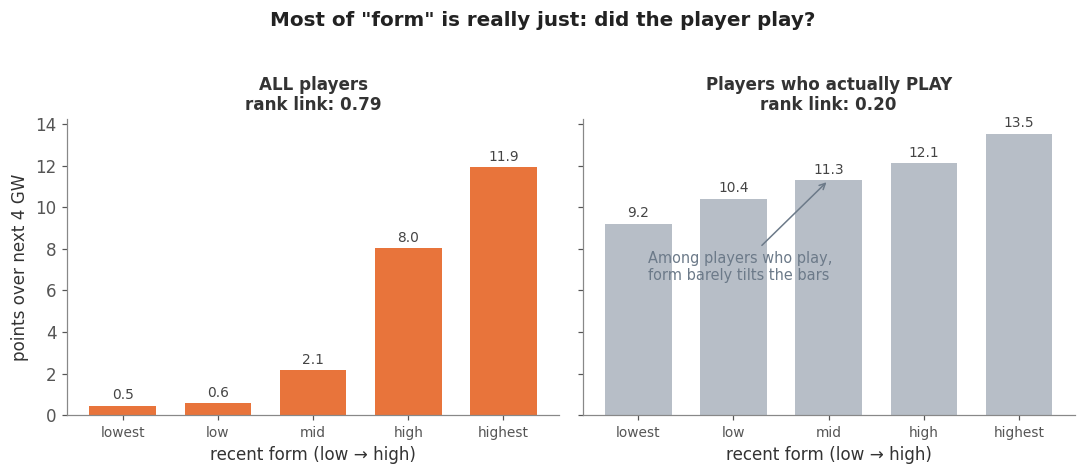

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
x = np.arange(5)
for ax, vals, color, sub in [
    (axes[0], next4_all, SIMPLE, 'ALL players\nrank link: 0.79'),
    (axes[1], next4_playing, GREY, 'Players who actually PLAY\nrank link: 0.20')]:
    ax.bar(x, vals, color=color, width=0.7)
    ax.set_title(sub, fontsize=11, color='#333')
    ax.set_xticks(x); ax.set_xticklabels(form_groups, fontsize=9)
    ax.set_xlabel('recent form (low → high)')
    for xi, v in zip(x, vals):
        ax.text(xi, v+0.3, f'{v:.1f}', ha='center', fontsize=9, color='#444')
axes[0].set_ylabel('points over next 4 GW')
axes[1].annotate('Among players who play,\nform barely tilts the bars',
                 xy=(2, 11.3), xytext=(0.1, 6.5), fontsize=9.5, color=MUTED,
                 arrowprops=dict(arrowstyle='->', color=MUTED))
fig.suptitle('Most of "form" is really just: did the player play?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('outputs/charts/01_availability_artifact.png', bbox_inches='tight'); plt.show()

## 2. The model *did* rank players well

So I split the job in two:

1. **Filter** — keep only players likely to start.
2. **Rank** — sort those starters by predicted points.

Among likely starters, the model ranked next-4-gameweek points **better than any simple signal**. The bar below is the rank link with what really happened (higher is better). This was the model's real strength.

This is still a *link*, not a cause. And it is about **prediction accuracy** — not yet about better decisions.

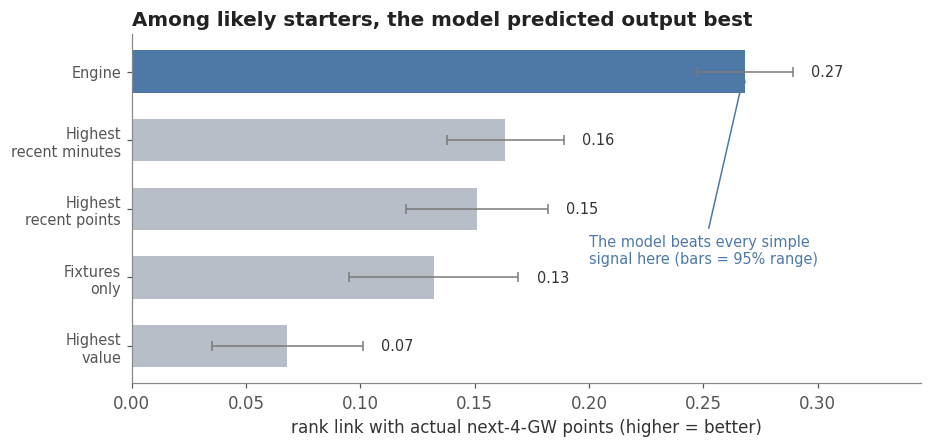

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
order = np.argsort(rank_vals)
names = [rank_names[i] for i in order]; vals=[rank_vals[i] for i in order]
lo=[rank_vals[i]-rank_lo[i] for i in order]; hi=[rank_hi[i]-rank_vals[i] for i in order]
colors=[ENGINE if rank_names[i]=='Engine' else GREY for i in order]
y=np.arange(len(names))
ax.barh(y, vals, xerr=[lo,hi], color=colors, height=0.62,
        error_kw=dict(ecolor='#7a7a7a', capsize=3, lw=1))
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9.5)
ax.set_xlabel('rank link with actual next-4-GW points (higher = better)')
for yi,v,h in zip(y,vals,[rank_hi[i] for i in order]):
    ax.text(h+0.008, yi, f'{v:.2f}', va='center', ha='left', fontsize=9.5, color='#333')
ax.set_xlim(0,0.345)
ax.annotate('The model beats every simple\nsignal here (bars = 95% range)',
            xy=(0.268, y[list(names).index("Engine")]), xytext=(0.20,1.2),
            fontsize=9.5, color=ENGINE, arrowprops=dict(arrowstyle='->',color=ENGINE))
ax.set_title('Among likely starters, the model predicted output best', loc='left')
plt.tight_layout(); plt.savefig('outputs/charts/02_engine_ranking.png', bbox_inches='tight'); plt.show()

## 3. But better ranking did **not** win the season

Here is the twist.

I ran a realistic season simulation. It used real squads, valid formations, a bench, a captain, free transfers, and point costs for extra transfers. I ran it from 40 different starting squads so I could measure how sure I am.

The model **beat doing nothing**. But it **lost to a simple rule**: *pick the highest recent scorers among likely starters*. The simple rule scored **159 more points** over the test weeks.

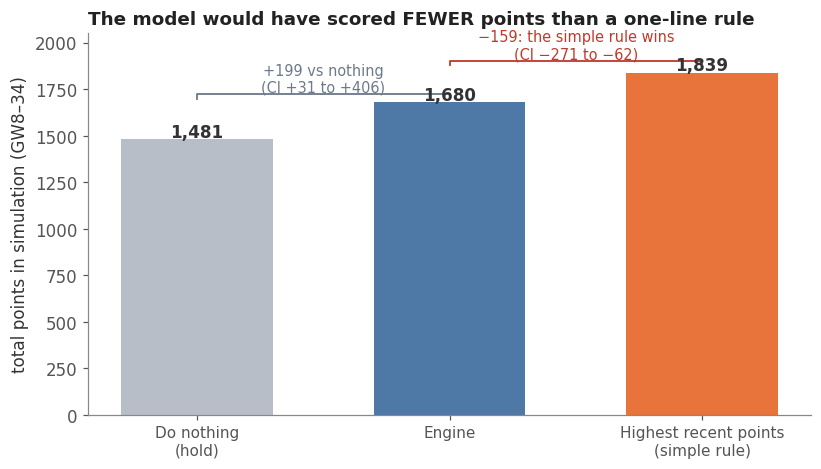

In [4]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
x=np.arange(3); colors=[GREY, ENGINE, SIMPLE]
ax.bar(x, sim_vals, color=colors, width=0.6)
for xi,v in zip(x,sim_vals): ax.text(xi, v+12, f'{v:,}', ha='center', fontsize=11, fontweight='bold', color='#333')
ax.set_xticks(x); ax.set_xticklabels(sim_names, fontsize=10)
ax.set_ylabel('total points in simulation (GW8–34)')
ax.set_ylim(0, 2050)
# brackets
def bracket(ax,x1,x2,y,txt,color):
    ax.plot([x1,x1,x2,x2],[y,y+22,y+22,y],lw=1.2,color=color)
    ax.text((x1+x2)/2, y+34, txt, ha='center', fontsize=9.5, color=color)
bracket(ax,0,1,1700,'+199 vs nothing\n(CI +31 to +406)',MUTED)
bracket(ax,1,2,1880,'−159: the simple rule wins\n(CI −271 to −62)',LOSS)
ax.set_title('The model would have scored FEWER points than a one-line rule', loc='left', fontsize=12)
plt.tight_layout(); plt.savefig('outputs/charts/03_decision_value.png', bbox_inches='tight'); plt.show()

## 4. The model lost on every part of the decision

I broke the weekly decision into parts: transfers, squad selection, and captaincy. I compared the model to the simple rule on each. **The model never came out ahead.**

- **Transfers:** a tie. The model is no better than the simple rule.
- **Squad selection:** the model loses.
- **Captaincy:** the model loses. Captaincy is about *upside* — who might explode this week. The model plays it safe, so it misses big hauls.

Each dot is *model minus simple rule*. Left of the line means the model is worse. The whisker is the 95% range. On the right, both rules beat my own real captain picks — but the simple rule did this **just as well** as the model.

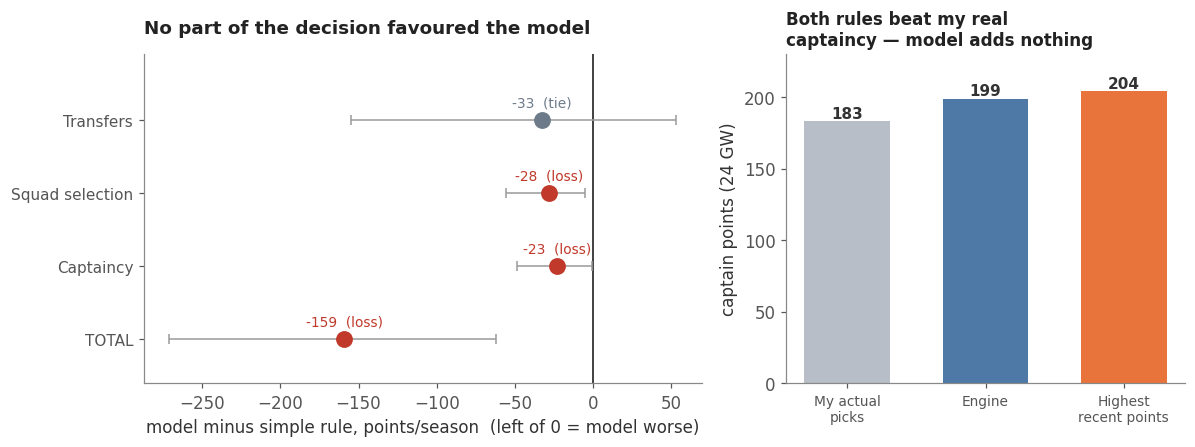

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'width_ratios':[1.4,1]})
# left: component dot plot
ax=axes[0]; y=np.arange(len(comp_names))[::-1]
xerr=[[comp_diff[i]-comp_lo[i] for i in range(4)],[comp_hi[i]-comp_diff[i] for i in range(4)]]
cols=[MUTED if comp_names[i]=='Transfers' else LOSS for i in range(4)]
ax.axvline(0, color='#444', lw=1.3)
ax.errorbar(comp_diff, y, xerr=xerr, fmt='o', ms=9, color='none',
            ecolor='#9a9a9a', capsize=3, lw=1)
for i,(d,yi,c) in enumerate(zip(comp_diff,y,cols)):
    ax.plot(d, yi, 'o', ms=10, color=c)
    tag = 'tie' if comp_names[i]=='Transfers' else 'loss'
    ax.text(d, yi+0.18, f'{d:+d}  ({tag})', ha='center', fontsize=9, color=c)
ax.set_yticks(y); ax.set_yticklabels(comp_names, fontsize=10)
ax.set_xlabel('model minus simple rule, points/season  (left of 0 = model worse)')
ax.set_ylim(-0.6, 3.9)
ax.set_title('No part of the decision favoured the model', loc='left', fontsize=12, pad=14)
# right: captaincy vs my actual
ax2=axes[1]; x=np.arange(3); cc=[GREY, ENGINE, SIMPLE]
ax2.bar(x, cap_vals, color=cc, width=0.62)
for xi,v in zip(x,cap_vals): ax2.text(xi,v+2,f'{v}',ha='center',fontsize=10,fontweight='bold',color='#333')
ax2.set_xticks(x); ax2.set_xticklabels(cap_names, fontsize=9)
ax2.set_ylabel('captain points (24 GW)'); ax2.set_ylim(0,230)
ax2.set_title('Both rules beat my real\ncaptaincy — model adds nothing', loc='left', fontsize=11)
plt.tight_layout(); plt.savefig('outputs/charts/04_component_breakdown.png', bbox_inches='tight'); plt.show()

## 5. My simple weekly rule for next season

The model predicts well but decides no better than a plain rule. So next season I will keep it simple and fast.

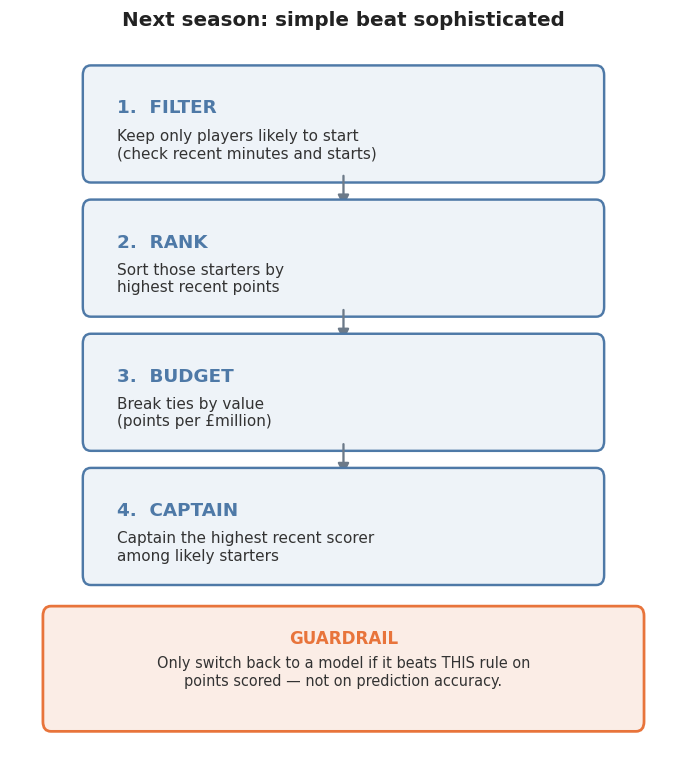

In [6]:
fig, ax = plt.subplots(figsize=(7.8, 8.4)); ax.axis('off')
steps = [
    ('1.  FILTER', 'Keep only players likely to start\n(check recent minutes and starts)'),
    ('2.  RANK', 'Sort those starters by\nhighest recent points'),
    ('3.  BUDGET', 'Break ties by value\n(points per £million)'),
    ('4.  CAPTAIN', 'Captain the highest recent scorer\namong likely starters'),
]
top0, h_box, gap = 0.95, 0.12, 0.045
for i,(h,b) in enumerate(steps):
    top = top0 - i*(h_box+gap)
    box=FancyBboxPatch((0.12, top-h_box), 0.76, h_box, boxstyle='round,pad=0.012',
                       fc='#EEF3F8', ec=ENGINE, lw=1.6); ax.add_patch(box)
    ax.text(0.16, top-0.040, h, fontsize=12, fontweight='bold', color=ENGINE, va='center')
    ax.text(0.16, top-0.085, b, fontsize=10, color='#333', va='center')
    if i<3:
        ax.add_patch(FancyArrowPatch((0.5, top-h_box),(0.5, top-h_box-gap),
            arrowstyle='-|>', mutation_scale=15, color=MUTED, lw=1.5))
# guardrail sits clearly below the 4th box
last_bottom = top0 - 3*(h_box+gap) - h_box
gtop = last_bottom - 0.05
g=FancyBboxPatch((0.06, gtop-0.13), 0.88, 0.13, boxstyle='round,pad=0.012',
                 fc='#FBEDE6', ec=SIMPLE, lw=1.8); ax.add_patch(g)
ax.text(0.5, gtop-0.034, 'GUARDRAIL', ha='center', fontsize=11, fontweight='bold', color=SIMPLE)
ax.text(0.5, gtop-0.085, 'Only switch back to a model if it beats THIS rule on\npoints scored — not on prediction accuracy.',
        ha='center', fontsize=9.5, color='#333')
ax.set_title('Next season: simple beat sophisticated', loc='center', fontsize=13)
ax.set_xlim(0,1); ax.set_ylim(gtop-0.16, 1.0)
plt.savefig('outputs/charts/05_weekly_rule.png', bbox_inches='tight'); plt.show()

## The big lesson

**A model can predict better and still decide worse.** Better forecasts are not the same as better choices.

The model's one real strength was ranking players who play. But once I added real FPL rules — squads, formations, captains, and transfer costs — a plain "highest recent points among likely starters" rule scored more. Captaincy is the clearest case: it rewards upside, and the safe model misses the big weeks.

So for next season I will trust the simple rule, and I will only build something fancier if it can beat that rule on **points**, not on prediction accuracy.

---
*Caveats: one season (2025/26); results are links and simulations, not causes; chip weeks were left out of the simulation; prices were partly reconstructed; the simulation is realistic but not perfect.*